 # what can we tune in Decision Tree?

Step 1 —

A decision tree splits data at each node to separate classes. The hyperparameters control how deep and complex the tree can grow. Deeper = more overfit. Shallower = more underfit.


In [1]:
# Key hyperparameters:
# max_depth         — max levels the tree can grow. None = unlimited (overfit)
# min_samples_split — min samples needed at a node to split it further
# min_samples_leaf  — min samples required at a leaf (end node)
# criterion         — how to measure quality of a split

# Overfit example: tree with depth 30 memorizes every training point
# Underfit example: tree with depth 2 can only make 4 predictions total

# max_depth is THE most important parameter to tune first.

In [ ]:
max_depth=None:
            Tree grows until all leaves are pure. Almost always overfits. Never use in practice.
max_depth=3:
            3 levels = max 8 leaf nodes. Simple, interpretable, might underfit
max_depth=7:
            Good starting point for most datasets. Balance of complexity
min_samples_split=2:
            Default. Any node with >=2 samples can be split. Leads to deep trees.
min_samples_split=10:
Node needs >=10 samples to split. Makes tree simpler, reduces overfit
criterion='gini':
            Gini impurity. Default. Slightly faster.
criterion='entropy':
            Information gain. Mathematically similar to gini. Results usually nearly identical.

Decision trees are highly interpretable — you can literally print the tree and show it in a presentation. Great for explaining model logic.

Step 2 — prepare data


Decision trees don't need feature scaling — they split on thresholds, so scale doesn't matter. Just split the data.

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# No scaling needed for tree-based models!
# Decision trees split on: "feature_X > threshold?" — scale doesn't matter.

In [ ]:
No scaling needed
            Trees make binary splits on feature values. Scaling X by 1000 doesn't change the split logic.
stratify=y
            Keep class proportions equal in both splits. Good practice.


This no-scaling property carries to Random Forest and XGBoost too. Only distance/gradient-based models (KNN, SVM, Logistic) need scaling.

Step 3 — GridSearchCV + visualize depth effect

In [3]:
param_grid = {
    'max_depth':         [2, 3, 4, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion':         ['gini', 'entropy']
}
# 7 x 4 x 2 = 56 combos × 5 folds = 280 fits

model = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

# See how depth affects train vs test accuracy
train_acc, val_acc = [], []
depths = range(1, 15)
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(dt.score(X_train, y_train))
    val_acc.append(dt.score(X_test, y_test))

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}
Best CV accuracy: 0.9417


In [ ]:
train_acc list
        Training accuracy. Increases (or stays 1.0) as depth increases — tree memorizes
val_acc list
        Test accuracy. Increases then decreases — the classic bias-variance curve
sweet spot
        The depth where val_acc is highest = optimal max_depth for your data

Plot train_acc vs val_acc against depth. The gap between them shows overfitting. Best depth = where val_acc peaks.

Step 4 — visualize tree + feature importance

Test accuracy: 0.9333333333333333


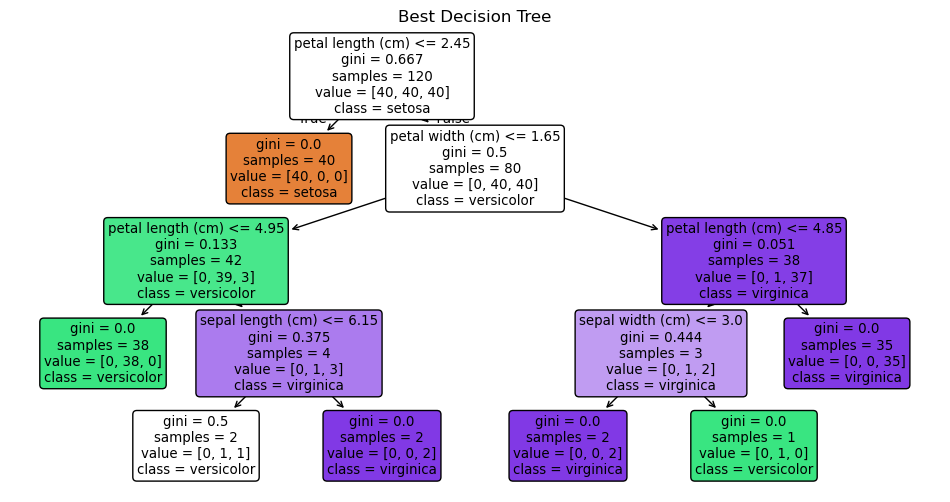

petal length (cm)    0.565639
petal width (cm)     0.411154
sepal width (cm)     0.016878
sepal length (cm)    0.006329
dtype: float64


In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd
best_dt = grid.best_estimator_
y_pred = best_dt.predict(X_test)
print("Test accuracy:", best_dt.score(X_test, y_test))

# Visualize the tree (keep max_depth low for readability)
plt.figure(figsize=(12, 6))
plot_tree(best_dt,
          feature_names=load_iris().feature_names,
          class_names=load_iris().target_names,
          filled=True,
          rounded=True)
plt.title("Best Decision Tree")
plt.show()

# Feature importance
importances = pd.Series(best_dt.feature_importances_,
                        index=load_iris().feature_names)
print(importances.sort_values(ascending=False))

In [ ]:
feature_importances_
            How much each feature contributed to the splits. Sum = 1.0
filled=True
            Colors nodes by majority class — makes tree much easier to read
plot_tree()
            Best used when max_depth <= 4. Deeper trees become unreadable